## 0. Imports and Data Loading

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from decimal import Decimal
os.chdir("..")
DATA_PATH = Path("data/credit_applications_with_age.csv")

In [14]:
# 1) Load flattened CSV from the engineering pipeline
df = pd.read_csv(DATA_PATH)

bias_cols = [
    "app_id",                          # record tracking
    "applicant_info.gender",           # protected attribute (gender DI)
    "age",                             # protected attribute (age bias)
    "applicant_info.zip_code",         # key proxy candidate
    "loan_purpose",                    # proxy/interaction candidate
    "financials.annual_income",        # proxy/interaction candidate
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "spending_behavior",               # proxy candidate (behavioral features)
    "decision.loan_approved",          # target outcome for fairness metrics
]

df = pd.read_csv(
    "data/credit_applications_with_age.csv",
    usecols=bias_cols
)

# Keep gender groups for DI
gender_df = df[df["applicant_info.gender"].isin(["Female", "Male"])].copy()

# Convert approval to numeric (assumes cleaned boolean/0-1 values)
gender_df["loan_approved_num"] = gender_df["decision.loan_approved"].astype(int)

# Ensure age is numeric (the CSV already provides this feature)
df["age"] = pd.to_numeric(df["age"], errors="coerce")
print(f"Rows used for analysis: {len(df)}")
df


Rows used for analysis: 495


,spending_behavior,app_id,loan_purpose,applicant_info.gender,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,age
0,"[{'category': 'Shopping', 'amount': 480}, {'ca...",app_200,Not Specified,Male,10036,73000.0,23,0.20,31212,False,25
1,"[{'category': 'Rent', 'amount': 608}, {'catego...",app_037,Not Specified,Male,10032,78000.0,51,0.18,17915,False,33
2,"[{'category': 'Rent', 'amount': 109}]",app_215,vacation,Male,10075,61000.0,41,0.21,37909,True,36
3,"[{'category': 'Fitness', 'amount': 575}]",app_024,Not Specified,Male,10077,103000.0,70,0.35,0,True,42
4,"[{'category': 'Entertainment', 'amount': 463}]",app_184,Not Specified,Male,10080,57000.0,14,0.23,31763,False,26
...,...,...,...,...,...,...,...,...,...,...,...
490,"[{'category': 'Transportation', 'amount': 701}]",app_468,Not Specified,Male,10046,22000.0,35,0.35,8982,False,26
491,"[{'category': 'Healthcare', 'amount': 650}]",app_192,Not Specified,Male,10088,78000.0,40,0.22,34292,True,40
492,"[{'category': 'Insurance', 'amount': 526}]",app_234,education,Male,10090,96000.0,60,0.30,38703,False,50
493,"[{'category': 'Insurance', 'amount': 490}]",app_306,Not Specified,Female,90227,106000.0,80,0.29,63560,True,47


## 1. Gender Disparate Impact

We define the Disparate Impact (DI) ratio as the project description did:

$$DI = \frac{\text{Approval rate (unprivileged group)}}{\text{Approval rate (privileged group)}}$$

A DI ratio below 0.8 indicates potential illegal disparate impact under US EEOC guidelines (the four-fifths rule).
We treat Male as the privileged group, since their historical approval rate is higher.

Female approval rate: 0.506
Male approval rate: 0.659
Disparate Impact (Female/Male): 0.7684
Potential disparate impact (DI < 0.8): True


,approval_rate
applicant_info.gender,
Female,0.506024
Male,0.658537


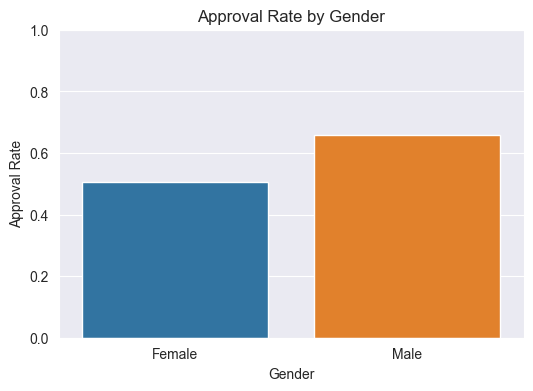

In [23]:
# Approval rates by gender
approval_by_gender = (
    gender_df.groupby("applicant_info.gender")["loan_approved_num"]
    .mean()
    .rename("approval_rate")
)

female_rate = approval_by_gender.loc["Female"]
male_rate = approval_by_gender.loc["Male"]

# Disparate Impact (Female / Male)
di_female = female_rate / male_rate
di_female_rounded = round(di_female, 4)
print(f"Female approval rate: {female_rate:.3f}")
print(f"Male approval rate: {male_rate:.3f}")
print(f"Disparate Impact (Female/Male): {di_female_rounded}")
print("Potential disparate impact (DI < 0.8):", di_female < 0.8)

display(approval_by_gender.to_frame())

# Approval-rate plot by gender
plot_df = approval_by_gender.rename_axis("gender").reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df, x="gender", y="approval_rate", hue="gender", legend=False)
plt.title("Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.show()

### Interpretation of Results:
The gender-based analysis reveals a statistically significant disparity in loan approval outcomes, with female applicants receiving approvals at a rate of 50.6% compared to 65.9% for male applicants—a gap of approximately 15.3 percentage points. This result translates to a Disparate Impact (DI) ratio of 0.768. Because this ratio falls below the 0.80 threshold established by the U.S. EEOC’s "four-fifths rule," it triggers a formal fairness warning. The statistical significance of this finding is further confirmed by a Chi-squared test, which yielded a p-value of $0.000813$. Since this is well below the $0.05$ significance level, the observed gender-approval association is highly unlikely to be the result of random variation. Ultimately, these results indicate that the historical decision pattern in this dataset favors male applicants, suggesting a need for urgent investigation into potential root causes—such as proxy variables or biased decision policies—to ensure compliance with fair lending standards.

## 1.2 Chi-squared test for statistical signifiance

In [24]:
# Chi-squared test of independence: gender vs approval outcome
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    gender_df["applicant_info.gender"],
    gender_df["loan_approved_num"],
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print("\nChi-squared test: Gender vs Loan Approval")
print(f"Chi2 statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print("Statistically significant at alpha=0.05:", p_value < 0.05)

display(contingency)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
display(expected_df)


Chi-squared test: Gender vs Loan Approval
Chi2 statistic: 11.2115
Degrees of freedom: 1
p-value: 0.000813
Statistically significant at alpha=0.05: True


loan_approved_num,0,1
applicant_info.gender,,
Female,123,126
Male,84,162


loan_approved_num,0,1
applicant_info.gender,,
Female,104.127273,144.872727
Male,102.872727,143.127273


This statistical evidence, combined with the Disparate Impact Ratio of 0.768, provides a robust case that the current system exhibits systemic gender bias. This confirms a Bias in Gender Loan Approval Rate

## 2. Age-Based Discrimination Patterns

We test whether approval outcomes differ systematically across age groups and compare younger/older applicants against a prime-age reference group.